# E5 — Path ablation (routing at t*)

Block attention from t* to source regions; writes at W left intact. Compare to E4 content patching.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))
import torch, pandas as pd
from IPython.display import display, Image
import transformer_lens as tl
from E5_path_ablation import run_item, OUT_DIR, plot_layer_sweep, plot_main_bars
torch.set_grad_enabled(False)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
from E4_content_patching import ITEMS


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer


,intervention,mean_delta,sem_delta
11,path_block_Wwin_L5-11,-2.295362,0.287980
18,path_block_ops2_L5-11,-0.796809,0.083905
0,path_block_W_only_L9-11,-0.651113,0.112186
16,path_block_Wwin_L9-11,-0.617796,0.126072
17,path_block_Wwin_L9H9,-0.534407,0.052131
19,path_block_ops2_L9-11,-0.072986,0.015804
20,path_block_randpos_L9-11,-0.056745,0.016667
21,path_block_revision_L9-11,-0.030584,0.017829


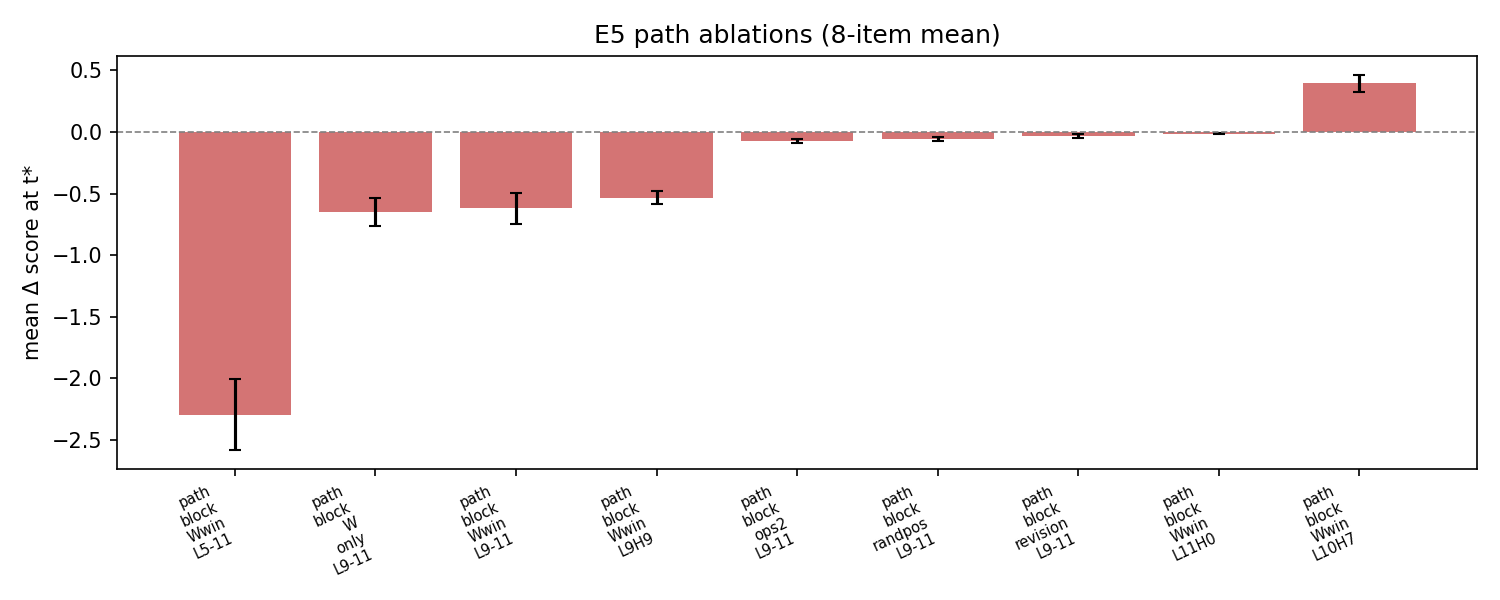

In [2]:
model = tl.HookedTransformer.from_pretrained('gpt2', device=DEVICE, fold_ln=False)
model.eval()
all_results = []
for item in ITEMS:
    all_results.extend(run_item(model, item))
import pandas as pd
rows=[{'item':r.item,'intervention':r.intervention,'baseline':r.baseline,'ablated':r.ablated,'delta':r.delta} for r in all_results]
df=pd.DataFrame(rows); OUT_DIR.mkdir(exist_ok=True); df.to_csv(OUT_DIR/'all_ablations.csv', index=False)
summary=df.groupby('intervention').agg(mean_delta=('delta','mean'),sem_delta=('delta','sem')).reset_index().sort_values('mean_delta')
display(summary[summary.intervention.str.contains('L5-11|L9-11|H9|rand')])
plot_layer_sweep(df,'per_layer_path_block.png'); plot_main_bars(summary.assign(mean_baseline=0,mean_ablated=0,n=8),'main_ablations.png')
Image(filename=OUT_DIR/'main_ablations.png')
